# NB4 — Train a small cardiac MRI segmentation U-Net

This notebook follows NB0–NB3: ACDC in `data/training`, labels 0=background,
1=RV, 2=myocardium, 3=LV. It is self-contained; earlier notebooks need not run.

Run cells in order in VS Code using **Python (heartmotion)**. Start with the
small-batch overfit check, inspect it, then run full training. The model starts
from random weights. No trained model or claimed accuracy is bundled.

Workflow: patient split → paired MRI/mask slices → 2D U-Net → native-grid masks
→ per-patient Dice and EDV/ESV/SV/EF errors → saved NIfTI predictions and checkpoint.
Validation selects the checkpoint, so it is a development set, not an untouched
final test set. The separate ACDC testing directory is used only by an optional
final cell that defaults to OFF.

This baseline preserves the full field of view by square-padding then resizing;
it does not use expert masks to locate a crop at inference. It is not nnU-Net,
and does not standardize physical pixel spacing across patients. Padding/resizing
loses detail; restoring the grid preserves coordinate correspondence, not lost
anatomical detail. No full-cycle motion or treatment-response claim is made.

## 1. Install once if necessary
Uncomment and run the next cell in your notebook kernel, then restart the kernel
if package installation requests it. The existing app remains independent of training.


In [3]:
# %pip install "torch>=2.2" nibabel numpy pandas matplotlib plotly scikit-image


In [6]:
import sys
print(sys.executable)

/opt/anaconda3/envs/heartmotion/bin/python


In [7]:
%pip install "torch>=2.2"

  Using cached filelock-4.0.1-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 872.6 kB/s  0:01:27 eta 0:00:010:00:05
Using cached fsspec-2026.9.0-py3-none-any.whl (221 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached filelock-4.0.1-py3-none-any.whl (106 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [torch]━━━━━ 4/5 [torch]]
Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration
`IMAGE_SIZE=192`, `BASE_CHANNELS=16`, and `BATCH_SIZE=8` are starting choices,
not tuned settings. Reduce batch size to 4 or 2 if memory runs out. For a quick
pipeline rehearsal use 2 epochs; that is not enough to assume useful accuracy.
The first epoch gives a much better runtime estimate than a fixed promise.

Every execution creates a new run folder so previous checkpoints are preserved.
Seeds reduce variation; GPU/MPS results may still vary across hardware and runs.


In [8]:
from pathlib import Path
from functools import lru_cache
from datetime import datetime
import json
import random
import time
import platform
import warnings

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'training').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook under hackMIT with data/training present.')
TRAIN_DIR = ROOT / 'data' / 'training'
TEST_DIR = ROOT / 'data' / 'testing'
SEED = 42
IMAGE_SIZE = 192
BASE_CHANNELS = 16
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 8
VAL_FRACTION = 0.20
RUN_OVERFIT_CHECK = True
OVERFIT_STEPS = 150
RUN_TRAINING = True
RUN_FINAL_TEST = False
assert IMAGE_SIZE >= 32 and IMAGE_SIZE % 8 == 0
RUN_DIR = ROOT / 'outputs' / 'unet' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
RUN_DIR.mkdir(parents=True, exist_ok=False)
BEST_PATH = RUN_DIR / 'best_unet.pt'
LABELS = {1: 'RV', 2: 'MYO', 3: 'LV'}

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print('Project:', ROOT)
print('Device:', DEVICE, '| Torch:', torch.__version__)
print('Run outputs:', RUN_DIR)


Project: /Users/Sincl/hackmit/hackMIT
Device: mps | Torch: 2.14.0
Run outputs: /Users/Sincl/hackmit/hackMIT/outputs/unet/20260919_193223_583590


## 3. Index patients and split BEFORE making slices
The split is stratified within each available ACDC group. For the full 100-patient
training set this gives 80 training and 20 validation patients (16/4 per group).
Both phases and all slices from one patient always stay together.
Missing files fail explicitly instead of silently changing the cohort.


In [9]:
def read_patient_info(patient_dir):
    info = {}
    for line in (Path(patient_dir) / 'Info.cfg').read_text().splitlines():
        if ':' in line:
            key, value = line.split(':', 1)
            info[key.strip()] = value.strip()
    return info

def phase_paths(patient_dir, phase):
    patient_dir = Path(patient_dir)
    info = read_patient_info(patient_dir)
    frame = int(info[phase])
    stem = f'{patient_dir.name}_frame{frame:02d}'
    return patient_dir / f'{stem}.nii.gz', patient_dir / f'{stem}_gt.nii.gz'

def index_patients(directory):
    rows = []
    for folder in sorted(Path(directory).glob('patient*')):
        if not folder.is_dir():
            continue
        info = read_patient_info(folder)
        for phase in ('ED', 'ES'):
            for file in phase_paths(folder, phase):
                if not file.is_file():
                    raise FileNotFoundError(file)
        rows.append({'Patient': folder.name, 'Group': info.get('Group', 'Unknown'),
                     'Folder': str(folder)})
    if not rows:
        raise ValueError(f'No labeled patients found in {directory}')
    return pd.DataFrame(rows)

patient_df = index_patients(TRAIN_DIR)
rng = np.random.default_rng(SEED)
train_ids, val_ids = [], []
for group, frame in patient_df.groupby('Group', sort=True):
    ids = rng.permutation(sorted(frame['Patient'].tolist())).tolist()
    if len(ids) < 2:
        raise ValueError(f'Need at least two patients in group {group} to stratify.')
    n_val = min(len(ids)-1, max(1, round(len(ids)*VAL_FRACTION)))
    val_ids.extend(ids[:n_val])
    train_ids.extend(ids[n_val:])
train_ids, val_ids = sorted(train_ids), sorted(val_ids)
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids + val_ids) == set(patient_df['Patient'])
patient_df['Split'] = np.where(patient_df['Patient'].isin(train_ids), 'train', 'validation')
patient_df.to_csv(RUN_DIR / 'patient_split.csv', index=False)
print(pd.crosstab(patient_df['Group'], patient_df['Split']))


Split  train  validation
Group                   
DCM       16           4
HCM       16           4
MINF      16           4
NOR       16           4
RV        16           4


## 4. Load and prepare volumes
NiBabel arrays keep their original `(X, Y, Z)` ordering. Each `[:, :, z]` is
processed consistently as a 2D image; transposing is used only for display.

Intensity preprocessing is computed from the MRI alone: clip the nonzero-voxel
1st/99th percentiles, then standardize nonzero voxels. Original zero background
stays zero. Constant/all-zero volumes become zeros. Geometry and labels are checked.
The raw-volume cache holds at most eight phase volumes. Prepared slices are cached
in RAM once (typically a few hundred MB for ACDC at 192 pixels) to avoid repeatedly
decompressing NIfTI files during shuffled training. No multi-worker loading is used on Mac.


In [10]:
def normalize_volume(image):
    image = np.asarray(image, dtype=np.float32)
    if not np.isfinite(image).all():
        raise ValueError('Nonfinite MRI intensities.')
    valid = image != 0
    out = np.zeros_like(image)
    if valid.any():
        lo, hi = np.percentile(image[valid], [1, 99])
        values = np.clip(image[valid], lo, hi)
        out[valid] = (values-values.mean()) / max(float(values.std()), 1e-6)
    return out

@lru_cache(maxsize=8)
def load_pair(folder, phase):
    image_path, mask_path = phase_paths(folder, phase)
    image_nii, mask_nii = nib.load(image_path), nib.load(mask_path)
    image = image_nii.get_fdata(dtype=np.float32)
    mask = mask_nii.get_fdata(dtype=np.float32)
    if image.ndim != 3 or image.shape != mask.shape:
        raise ValueError(f'Image/mask shape mismatch: {folder} {phase}')
    if not np.allclose(image_nii.affine, mask_nii.affine, atol=1e-4):
        raise ValueError(f'Image/mask affine mismatch: {folder} {phase}')
    if not np.isin(mask, [0, 1, 2, 3]).all():
        raise ValueError(f'Unexpected mask labels: {folder} {phase}')
    spacing = np.asarray(image_nii.header.get_zooms()[:3], dtype=float)
    units = image_nii.header.get_xyzt_units()[0]
    if units not in ('mm', 'unknown'):
        raise ValueError(f'Expected mm geometry, got {units}')
    if not np.isfinite(spacing).all() or (spacing <= 0).any():
        raise ValueError('Invalid voxel spacing.')
    return normalize_volume(image), mask.astype(np.uint8), spacing

def square_pad(tensor):
    h, w = tensor.shape[-2:]
    side = max(h, w)
    top, left = (side-h)//2, (side-w)//2
    pads = (left, side-w-left, top, side-h-top)
    return F.pad(tensor, pads, value=0), (h, w, top, left, side)

def prepare_slice(image, mask=None, size=IMAGE_SIZE):
    x = torch.from_numpy(np.array(image, dtype=np.float32, copy=True))[None, None]
    x, geometry = square_pad(x)
    x = F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)[0]
    y = None
    if mask is not None:
        y = torch.from_numpy(np.array(mask, dtype=np.float32, copy=True))[None, None]
        y, _ = square_pad(y)
        y = F.interpolate(y, size=(size, size), mode='nearest')[0, 0].long()
    return x, y, geometry

def restore_logits(logits, geometry):
    # Interpolate class logits, remove padding, THEN choose the class.
    h, w, top, left, side = geometry
    native = F.interpolate(logits, size=(side, side), mode='bilinear', align_corners=False)
    return native[:, :, top:top+h, left:left+w]

class ACDCSlices(Dataset):
    def __init__(self, rows, augment=False):
        self.items = []
        self.samples = []
        self.augment = augment
        for folder in rows['Folder']:
            for phase in ('ED', 'ES'):
                image, mask, _ = load_pair(folder, phase)
                for z in range(image.shape[2]):
                    self.items.append((folder, phase, z))
                    x, y, _ = prepare_slice(image[:, :, z], mask[:, :, z])
                    self.samples.append((x, y.to(torch.uint8)))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, index):
        x, y = self.samples[index]
        y = y.long()
        if self.augment:
            # Apply exactly the same flip to image and target.
            for axis in (-1, -2):
                if torch.rand(()) < 0.5:
                    x, y = x.flip(axis), y.flip(axis)
        return x, y

train_rows = patient_df[patient_df['Split'] == 'train']
val_rows = patient_df[patient_df['Split'] == 'validation']
train_ds = ACDCSlices(train_rows, augment=True)
val_ds = ACDCSlices(val_rows, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('Slices:', len(train_ds), 'train /', len(val_ds), 'validation')
print('All slices are included, including background-only slices.')


Slices: 1530 train / 372 validation
All slices are included, including background-only slices.


## 5. Inspect a training pair before training
You should see the target boundaries align with the MRI. Colors: blue RV,
gold myocardium, pink LV. Stop and inspect preprocessing if alignment is wrong.


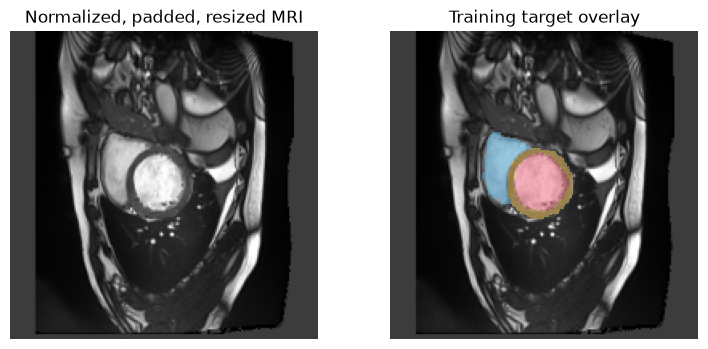

In [11]:
COLORMAP = ListedColormap(['black', '#58b4e5', '#eebd54', '#ef657a'])
preview_folder = train_rows.iloc[0]['Folder']
preview_image, preview_mask, _ = load_pair(preview_folder, 'ED')
preview_z = int(np.argmax((preview_mask > 0).sum(axis=(0, 1))))
preview_x, preview_y, _ = prepare_slice(preview_image[:, :, preview_z], preview_mask[:, :, preview_z])
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax in axes:
    ax.imshow(preview_x[0].numpy().T, cmap='gray', origin='lower')
    ax.axis('off')
axes[1].imshow(np.ma.masked_equal(preview_y.numpy().T, 0), cmap=COLORMAP,
               vmin=0, vmax=3, origin='lower', alpha=0.5, interpolation='nearest')
axes[0].set_title('Normalized, padded, resized MRI')
axes[1].set_title('Training target overlay')
plt.show()


## 6. Small 2D U-Net and loss
Three downsampling stages, skip connections, and 4 output logits per pixel.
GroupNorm avoids dependence on large batch sizes. Cross-entropy includes background;
soft Dice averages only the three foreground classes. This is a baseline, not a
claim of state-of-the-art performance.


In [12]:
class DoubleConv(nn.Module):
    def __init__(self, inputs, outputs):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inputs, outputs, 3, padding=1, bias=False),
            nn.GroupNorm(4, outputs), nn.ReLU(inplace=True),
            nn.Conv2d(outputs, outputs, 3, padding=1, bias=False),
            nn.GroupNorm(4, outputs), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        assert base % 4 == 0
        self.e1 = DoubleConv(1, base)
        self.e2 = DoubleConv(base, base*2)
        self.e3 = DoubleConv(base*2, base*4)
        self.bottom = DoubleConv(base*4, base*8)
        self.d3 = DoubleConv(base*12, base*4)
        self.d2 = DoubleConv(base*6, base*2)
        self.d1 = DoubleConv(base*3, base)
        self.out = nn.Conv2d(base, 4, 1)
    def forward(self, x):
        a = self.e1(x)
        b = self.e2(F.max_pool2d(a, 2))
        c = self.e3(F.max_pool2d(b, 2))
        d = self.bottom(F.max_pool2d(c, 2))
        def up_join(x, skip):
            return torch.cat([F.interpolate(x, size=skip.shape[-2:],
                              mode='bilinear', align_corners=False), skip], dim=1)
        x = self.d3(up_join(d, c))
        x = self.d2(up_join(x, b))
        return self.out(self.d1(up_join(x, a)))

def segmentation_loss(logits, target):
    ce = F.cross_entropy(logits, target)
    probs = logits.softmax(dim=1)
    truth = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * truth).sum(dims)
    dice = (2*intersection + 1e-5) / (probs.sum(dims) + truth.sum(dims) + 1e-5)
    return ce + (1-dice[1:].mean())

def hard_dice(prediction, reference, label):
    pred, ref = prediction == label, reference == label
    denominator = int(pred.sum()) + int(ref.sum())
    # Both absent => undefined, omitted from averages rather than rewarded as perfect.
    return 2*int((pred & ref).sum())/denominator if denominator else np.nan

def synchronize():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elif DEVICE.type == 'mps':
        torch.mps.synchronize()

print('Parameters:', f'{sum(p.numel() for p in SmallUNet(BASE_CHANNELS).parameters()):,}')


Parameters: 487,764


## 7. Overfit sanity check (training examples only)
A separate disposable network memorizes up to four foreground-rich training slices.
Loss should fall and masks should become recognizable. This is NOT validation.
If it fails, inspect preprocessing/optimization before spending time on full training.
The full model is initialized again from scratch after this cell.


Overfit step 1: loss=2.1703
Overfit step 25: loss=1.4289
Overfit step 50: loss=1.2528
Overfit step 75: loss=0.9795
Overfit step 100: loss=0.7622
Overfit step 125: loss=0.5794
Overfit step 150: loss=0.4288
Training-batch Dice: {'RV': 0.9613171989684587, 'MYO': 0.9098301841664673, 'LV': 0.9715481171548117}


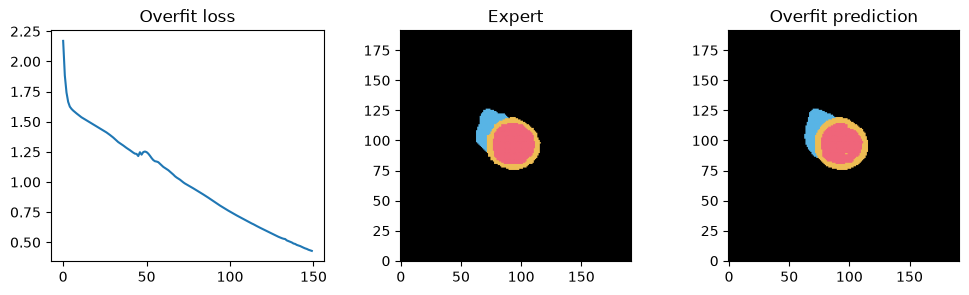

In [13]:
if RUN_OVERFIT_CHECK:
    candidates = np.argsort((preview_mask > 0).sum(axis=(0, 1)))[-min(4, preview_mask.shape[2]):]
    pairs = [prepare_slice(preview_image[:, :, z], preview_mask[:, :, z]) for z in candidates]
    tiny_x = torch.stack([p[0] for p in pairs]).to(DEVICE)
    tiny_y = torch.stack([p[1] for p in pairs]).to(DEVICE)
    tiny_model = SmallUNet(BASE_CHANNELS).to(DEVICE)
    tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=LEARNING_RATE)
    tiny_losses = []
    tiny_model.train()
    for step in range(OVERFIT_STEPS):
        tiny_optimizer.zero_grad(set_to_none=True)
        loss = segmentation_loss(tiny_model(tiny_x), tiny_y)
        if not torch.isfinite(loss):
            raise RuntimeError('Nonfinite overfit loss.')
        loss.backward()
        tiny_optimizer.step()
        tiny_losses.append(float(loss.detach().cpu()))
        if step == 0 or (step+1) % 25 == 0:
            print(f'Overfit step {step+1}: loss={tiny_losses[-1]:.4f}')
    tiny_model.eval()
    with torch.no_grad():
        tiny_prediction = tiny_model(tiny_x).argmax(1).cpu().numpy()
    tiny_reference = tiny_y.cpu().numpy()
    print('Training-batch Dice:', {name: hard_dice(tiny_prediction, tiny_reference, label)
                                   for label, name in LABELS.items()})
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    axes[0].plot(tiny_losses); axes[0].set_title('Overfit loss')
    axes[1].imshow(tiny_reference[0].T, cmap=COLORMAP, vmin=0, vmax=3, origin='lower')
    axes[1].set_title('Expert')
    axes[2].imshow(tiny_prediction[0].T, cmap=COLORMAP, vmin=0, vmax=3, origin='lower')
    axes[2].set_title('Overfit prediction')
    plt.show()
    del tiny_model, tiny_optimizer, tiny_x, tiny_y
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()


## 8. Train and save the best checkpoint
The validation loss selects the checkpoint. Epoch Dice below is a pooled,
resized-grid monitoring score, not the final patient-level native-grid result.
A checkpoint is saved after every completed epoch that improves validation loss.
If you interrupt, the best completed epoch remains available; run the reload cell.
This cell starts a NEW model when rerun, not a resumed optimizer state.


Epoch 01 | train 1.3052 | val 1.0829 | val Dice 0.065 | 32.5s
Epoch 02 | train 0.9831 | val 0.9241 | val Dice 0.101 | 30.0s
Epoch 03 | train 0.8820 | val 0.8716 | val Dice 0.088 | 30.0s
Epoch 04 | train 0.8254 | val 0.8174 | val Dice 0.277 | 30.2s
Epoch 05 | train 0.5822 | val 0.4389 | val Dice 0.697 | 31.2s
Epoch 06 | train 0.3408 | val 0.3665 | val Dice 0.750 | 31.6s
Epoch 07 | train 0.2890 | val 0.3528 | val Dice 0.754 | 31.3s
Epoch 08 | train 0.2449 | val 0.2604 | val Dice 0.820 | 30.1s
Epoch 09 | train 0.2148 | val 0.2304 | val Dice 0.842 | 30.1s
Epoch 10 | train 0.2150 | val 0.2153 | val Dice 0.851 | 30.1s
Epoch 11 | train 0.1891 | val 0.2034 | val Dice 0.859 | 31.2s
Epoch 12 | train 0.1773 | val 0.1925 | val Dice 0.866 | 30.3s
Epoch 13 | train 0.1722 | val 0.1851 | val Dice 0.872 | 30.6s
Epoch 14 | train 0.1644 | val 0.1746 | val Dice 0.875 | 31.5s
Epoch 15 | train 0.1579 | val 0.1870 | val Dice 0.871 | 30.0s
Epoch 16 | train 0.1562 | val 0.1724 | val Dice 0.881 | 31.7s
Epoch 17

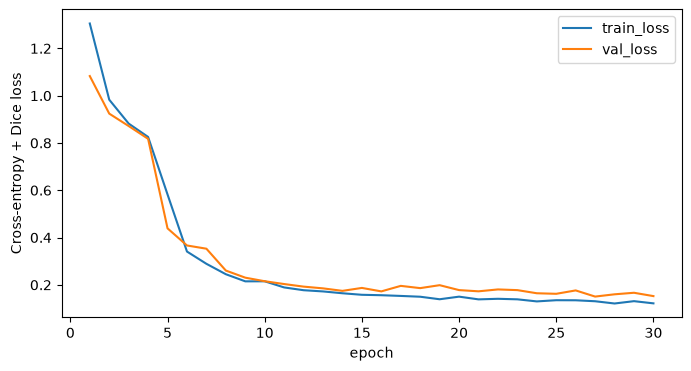

In [14]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, total_samples = 0.0, 0
    intersections = np.zeros(3, dtype=np.float64)
    denominators = np.zeros(3, dtype=np.float64)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = segmentation_loss(logits, y)
            if not torch.isfinite(loss):
                raise RuntimeError('Nonfinite loss; inspect inputs and learning rate.')
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
        total_loss += float(loss.detach().cpu()) * x.shape[0]
        total_samples += x.shape[0]
        pred = logits.detach().argmax(1)
        for k, label in enumerate(LABELS):
            p, r = pred == label, y == label
            intersections[k] += float((p & r).sum().cpu())
            denominators[k] += float((p.sum()+r.sum()).cpu())
    dice = np.divide(2*intersections, denominators,
                     out=np.full(3, np.nan), where=denominators > 0)
    return total_loss/total_samples, float(np.nanmean(dice))

config = dict(seed=SEED, image_size=IMAGE_SIZE, base_channels=BASE_CHANNELS,
              batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LEARNING_RATE,
              patience=PATIENCE, normalization='nonzero_p1_p99_zscore_volume',
              geometry='square_pad_bilinear_resize; nearest_mask; restore_logits_then_argmax',
              label_map={str(k): v for k, v in LABELS.items()},
              train_ids=train_ids, val_ids=val_ids,
              torch_version=str(torch.__version__), python_version=platform.python_version(),
              device=str(DEVICE))
(RUN_DIR / 'config.json').write_text(json.dumps(config, indent=2))
if RUN_TRAINING:
    seed_everything(SEED)
    model = SmallUNet(BASE_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_loss, stale_epochs, history = float('inf'), 0, []
    try:
        for epoch in range(1, EPOCHS+1):
            synchronize(); started = time.perf_counter()
            train_loss, train_dice = run_epoch(model, train_loader, optimizer)
            val_loss, val_dice = run_epoch(model, val_loader)
            synchronize(); elapsed = time.perf_counter()-started
            history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                                train_dice=train_dice, val_dice=val_dice, seconds=elapsed))
            if val_loss < best_loss:
                best_loss, stale_epochs = val_loss, 0
                checkpoint = dict(model_state={k: v.detach().cpu().clone()
                                               for k, v in model.state_dict().items()},
                                  epoch=epoch, validation_loss=val_loss, config=config)
                temporary = BEST_PATH.with_suffix('.tmp')
                torch.save(checkpoint, temporary)
                temporary.replace(BEST_PATH)
            else:
                stale_epochs += 1
            pd.DataFrame(history).to_csv(RUN_DIR / 'training_history.csv', index=False)
            print(f'Epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f} | '
                  f'val Dice {val_dice:.3f} | {elapsed:.1f}s', flush=True)
            if stale_epochs >= PATIENCE:
                print('Early stopping.'); break
    except KeyboardInterrupt:
        print('Interrupted. Best checkpoint from a completed epoch:', BEST_PATH)
    if history:
        pd.DataFrame(history).plot(x='epoch', y=['train_loss', 'val_loss'], figsize=(8, 4))
        plt.ylabel('Cross-entropy + Dice loss'); plt.show()


## 9. Reload the selected model and define native-grid prediction
To evaluate a prior run after restarting: set `CHECKPOINT_TO_LOAD` to its
`best_unet.pt`. The saved model size and preprocessing size are loaded from it.
Only load checkpoints you created or trust.

Inference takes an MRI path only; it never reads the expert mask. Logits are
restored to the original XY shape before argmax. Slices are stacked in original
Z order. Native voxel spacing remains applicable to the saved prediction.


In [15]:
CHECKPOINT_TO_LOAD = BEST_PATH  # Or Path('/absolute/path/to/previous/best_unet.pt')
if not CHECKPOINT_TO_LOAD.is_file():
    raise FileNotFoundError('No checkpoint yet: finish at least one training epoch or select a prior checkpoint.')
checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location='cpu', weights_only=True)
model = SmallUNet(checkpoint['config']['base_channels'])
model.load_state_dict(checkpoint['model_state'])
model = model.to(DEVICE).eval()
INFERENCE_SIZE = checkpoint['config']['image_size']
EVAL_DIR = CHECKPOINT_TO_LOAD.parent
print('Loaded epoch', checkpoint['epoch'], 'from', CHECKPOINT_TO_LOAD)

@torch.no_grad()
def predict_volume(image_path, batch_size=BATCH_SIZE):
    nii = nib.load(image_path)
    image = nii.get_fdata(dtype=np.float32)
    if image.ndim != 3:
        raise ValueError('Expected a single 3D ED/ES MRI volume.')
    normalized = normalize_volume(image)
    prediction = np.zeros(image.shape, dtype=np.uint8)
    model.eval()
    for start in range(0, image.shape[2], batch_size):
        stop = min(start+batch_size, image.shape[2])
        prepared = [prepare_slice(normalized[:, :, z], size=INFERENCE_SIZE)
                    for z in range(start, stop)]
        x = torch.stack([p[0] for p in prepared]).to(DEVICE)
        # Restore on CPU to keep full-resolution logits off the accelerator.
        logits = model(x).cpu()
        restored = restore_logits(logits, prepared[0][2])
        prediction[:, :, start:stop] = restored.argmax(1).numpy().astype(np.uint8).transpose(1, 2, 0)
    return prediction, nii

def save_prediction(prediction, reference_nii, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    header = reference_nii.header.copy()
    header.set_data_dtype(np.uint8)
    header.set_slope_inter(1, 0)
    output = nib.Nifti1Image(prediction.astype(np.uint8), reference_nii.affine, header)
    qform, qcode = reference_nii.get_qform(coded=True)
    sform, scode = reference_nii.get_sform(coded=True)
    output.set_qform(qform, int(qcode))
    output.set_sform(sform, int(scode))
    nib.save(output, destination)


Loaded epoch 27 from /Users/Sincl/hackmit/hackMIT/outputs/unet/20260919_193223_583590/best_unet.pt


## 10. Evaluate held-out validation patients in ORIGINAL geometry
Dice is calculated per 3D patient-phase-structure, then averaged across patients
within each phase. Both-absent structures get NaN; a missing prediction for a
present reference gets Dice 0. Counts are reported with means.

Volumes use each phase's own voxel spacing. EF errors are percentage points.
Zero predicted EDV gives undefined EF, never a silently fabricated zero. Report
valid counts and review flags alongside average errors; do not hide failed cases.
Predictions use `_pred.nii.gz`, never overwrite `_gt.nii.gz`.


In [16]:
def chamber_metrics(ed_mask, es_mask, ed_spacing, es_spacing, label):
    edv = float(np.count_nonzero(ed_mask == label)*np.prod(ed_spacing)/1000)
    esv = float(np.count_nonzero(es_mask == label)*np.prod(es_spacing)/1000)
    return {'EDV_mL': edv, 'ESV_mL': esv, 'SV_mL': edv-esv,
            'EF_percent': 100*(edv-esv)/edv if edv > 0 else np.nan}

def evaluate_patients(rows, split_name):
    dice_rows, metric_rows, flags = [], [], []
    destination = EVAL_DIR / split_name
    destination.mkdir(exist_ok=True)
    for record in rows.to_dict('records'):
        patient, folder = record['Patient'], record['Folder']
        phases = {}
        for phase in ('ED', 'ES'):
            image_path, mask_path = phase_paths(folder, phase)
            _, reference, spacing = load_pair(folder, phase)
            prediction, image_nii = predict_volume(image_path)
            assert prediction.shape == reference.shape
            save_prediction(prediction, image_nii, destination / 'predictions' /
                            patient / image_path.name.replace('.nii.gz', '_pred.nii.gz'))
            if image_nii.header.get_xyzt_units()[0] == 'unknown':
                flags.append({'Patient': patient, 'Phase': phase, 'Issue': 'Spatial units unspecified; assumed mm (ACDC).'})
            for label, structure in LABELS.items():
                dice_rows.append(dict(Patient=patient, Group=record['Group'], Phase=phase,
                                      Structure=structure, Dice=hard_dice(prediction, reference, label)))
                if not np.any(prediction == label):
                    flags.append({'Patient': patient, 'Phase': phase, 'Issue': f'Missing predicted {structure}'})
            phases[phase] = (prediction, reference, spacing)
        for name, label in [('LV', 3), ('RV', 1)]:
            pred = chamber_metrics(phases['ED'][0], phases['ES'][0], phases['ED'][2], phases['ES'][2], label)
            ref = chamber_metrics(phases['ED'][1], phases['ES'][1], phases['ED'][2], phases['ES'][2], label)
            for source, values in [('predicted', pred), ('reference', ref)]:
                if values['EDV_mL'] <= 0 or values['ESV_mL'] <= 0 or values['SV_mL'] < 0:
                    flags.append({'Patient': patient, 'Phase': 'ED/ES', 'Issue': f'{name}: unusual {source} volumes'})
            for metric in ref:
                metric_rows.append(dict(Patient=patient, Group=record['Group'], Ventricle=name,
                                        Metric=metric, Reference=ref[metric], Predicted=pred[metric],
                                        Signed_Error=pred[metric]-ref[metric],
                                        Absolute_Error=abs(pred[metric]-ref[metric])))
        print('Evaluated', patient, flush=True)
    dice_df = pd.DataFrame(dice_rows)
    metric_df = pd.DataFrame(metric_rows)
    flags_df = pd.DataFrame(flags, columns=['Patient', 'Phase', 'Issue'])
    dice_df.to_csv(destination / 'dice_per_patient.csv', index=False)
    metric_df.to_csv(destination / 'clinical_errors.csv', index=False)
    flags_df.to_csv(destination / 'review_flags.csv', index=False)
    (destination / 'provenance.json').write_text(json.dumps({
        'checkpoint': str(CHECKPOINT_TO_LOAD), 'epoch': checkpoint['epoch'],
        'split': split_name, 'patients': rows['Patient'].tolist(),
        'postprocessing': 'none', 'normalization': checkpoint['config']['normalization']}, indent=2))
    return dice_df, metric_df, flags_df

saved_val_ids = checkpoint['config']['val_ids']
validation_rows = index_patients(TRAIN_DIR).set_index('Patient').loc[saved_val_ids].reset_index()
assert set(saved_val_ids).isdisjoint(checkpoint['config']['train_ids'])
dice_df, clinical_df, flags_df = evaluate_patients(validation_rows, 'validation')
display(dice_df.groupby(['Phase', 'Structure'])['Dice'].agg(['mean', 'median', 'count']))
display(clinical_df.groupby(['Ventricle', 'Metric']).agg(
    MAE=('Absolute_Error', 'mean'), Bias=('Signed_Error', 'mean'),
    Valid_N=('Absolute_Error', 'count'), Total_N=('Patient', 'size')))
display(flags_df)


Evaluated patient008
Evaluated patient010
Evaluated patient015
Evaluated patient016
Evaluated patient028
Evaluated patient029
Evaluated patient030
Evaluated patient039
Evaluated patient047
Evaluated patient048
Evaluated patient053
Evaluated patient054
Evaluated patient063
Evaluated patient064
Evaluated patient074
Evaluated patient079
Evaluated patient083
Evaluated patient091
Evaluated patient096
Evaluated patient097


mean    median  count
Phase Structure                           
ED    LV         0.946466  0.955566     20
      MYO        0.843199  0.858392     20
      RV         0.900088  0.906118     20
ES    LV         0.889410  0.932861     20
      MYO        0.857274  0.852152     20
      RV         0.808520  0.857574     20

MAE       Bias  Valid_N  Total_N
Ventricle Metric                                            
LV        EDV_mL       7.135012  -5.670121       20       20
          EF_percent   4.041201  -2.237175       20       20
          ESV_mL       7.233518  -2.182875       20       20
          SV_mL        6.427292  -3.487247       20       20
RV        EDV_mL      12.096206  -7.981155       20       20
          EF_percent   9.553221  -7.334681       20       20
          ESV_mL      14.868540   4.419475       20       20
          SV_mL       15.748124 -12.400629       20       20

,Patient,Phase,Issue
0,patient008,ED,Spatial units unspecified; assumed mm (ACDC).
1,patient008,ES,Spatial units unspecified; assumed mm (ACDC).
2,patient010,ED,Spatial units unspecified; assumed mm (ACDC).
3,patient010,ES,Spatial units unspecified; assumed mm (ACDC).
4,patient015,ED,Spatial units unspecified; assumed mm (ACDC).
5,patient015,ES,Spatial units unspecified; assumed mm (ACDC).
6,patient016,ED,Spatial units unspecified; assumed mm (ACDC).
7,patient016,ES,Spatial units unspecified; assumed mm (ACDC).
8,patient028,ED,Spatial units unspecified; assumed mm (ACDC).
9,patient028,ES,Spatial units unspecified; assumed mm (ACDC).


In [20]:
print("DICE SCORES")
print(
    dice_df.groupby(["Phase", "Structure"])["Dice"]
    .agg(["mean", "median", "count"])
    .round(4)
    .to_string()
)

print("\nCARDIAC MEASUREMENT ERRORS")
print(
    clinical_df.groupby(["Ventricle", "Metric"])
    .agg(
        MAE=("Absolute_Error", "mean"),
        Bias=("Signed_Error", "mean"),
        Valid_N=("Absolute_Error", "count"),
        Total_N=("Patient", "size")
    )
    .round(4)
    .to_string()
)

print("\nREVIEW FLAGS")
print(flags_df.to_string(index=False) if not flags_df.empty else "No flags.")

DICE SCORES
                   mean  median  count
Phase Structure                       
ED    LV         0.9465  0.9556     20
      MYO        0.8432  0.8584     20
      RV         0.9001  0.9061     20
ES    LV         0.8894  0.9329     20
      MYO        0.8573  0.8522     20
      RV         0.8085  0.8576     20

CARDIAC MEASUREMENT ERRORS
                          MAE     Bias  Valid_N  Total_N
Ventricle Metric                                        
LV        EDV_mL       7.1350  -5.6701       20       20
          EF_percent   4.0412  -2.2372       20       20
          ESV_mL       7.2335  -2.1829       20       20
          SV_mL        6.4273  -3.4872       20       20
RV        EDV_mL      12.0962  -7.9812       20       20
          EF_percent   9.5532  -7.3347       20       20
          ESV_mL      14.8685   4.4195       20       20
          SV_mL       15.7481 -12.4006       20       20

REVIEW FLAGS
   Patient Phase                                         Issue
p

In [21]:
print("LOWEST DICE SCORES")
display(
    dice_df.sort_values("Dice")
    .head(10)
)

print("LARGEST EF ERRORS")
display(
    clinical_df[
        clinical_df["Metric"] == "EF_percent"
    ]
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

LOWEST DICE SCORES


,Patient,Group,Phase,Structure,Dice
75,patient063,NOR,ES,RV,0.481982
39,patient030,HCM,ES,RV,0.627479
57,patient048,MINF,ES,RV,0.667216
103,patient091,RV,ED,MYO,0.691511
27,patient028,HCM,ES,RV,0.720629
97,patient083,RV,ED,MYO,0.722839
35,patient029,HCM,ES,LV,0.731129
69,patient054,MINF,ES,RV,0.735755
101,patient083,RV,ES,LV,0.744593
33,patient029,HCM,ES,RV,0.746729


LARGEST EF ERRORS


,Patient,Group,Ventricle,Metric,Reference,Predicted,Signed_Error,Absolute_Error
103,patient063,NOR,RV,EF_percent,67.099351,30.962343,-36.137008,36.137008
71,patient047,MINF,RV,EF_percent,51.364764,27.550077,-23.814687,23.814687
131,patient083,RV,LV,EF_percent,54.757185,36.905358,-17.851827,17.851827
31,patient016,DCM,RV,EF_percent,30.917355,13.975943,-16.941412,16.941412
7,patient008,DCM,RV,EF_percent,47.776119,31.045291,-16.730829,16.730829
79,patient048,MINF,RV,EF_percent,64.071038,48.538231,-15.532807,15.532807
23,patient015,DCM,RV,EF_percent,46.813114,33.492823,-13.320291,13.320291
99,patient063,NOR,LV,EF_percent,72.927410,59.756098,-13.171312,13.171312
55,patient030,HCM,RV,EF_percent,85.941946,75.162338,-10.779609,10.779609
159,patient097,RV,RV,EF_percent,38.183161,28.729661,-9.453500,9.453500


## 11. Inspect one held-out case: MRI, expert mask, predicted mask
The default is the first validation patient, not the best-performing patient.
Change `DEMO_PATIENT`, `DEMO_PHASE`, or `SLICE` to inspect failures too.


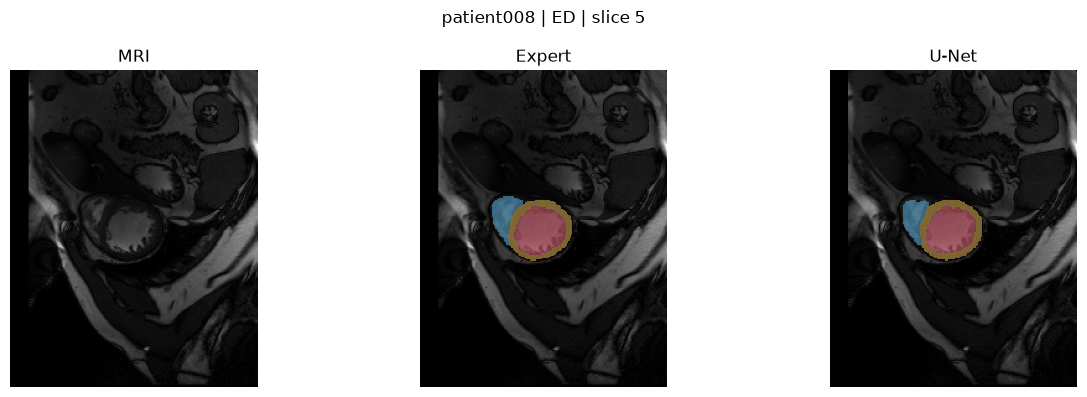

In [17]:
DEMO_PATIENT = saved_val_ids[0]
DEMO_PHASE = 'ED'
SLICE = None  # None uses the middle slice; otherwise a zero-based slice index.
demo_folder = TRAIN_DIR / DEMO_PATIENT
image_path, mask_path = phase_paths(demo_folder, DEMO_PHASE)
demo_nii = nib.load(image_path)
demo_image = demo_nii.get_fdata(dtype=np.float32)
demo_reference = nib.load(mask_path).get_fdata().astype(np.uint8)
prediction_path = EVAL_DIR / 'validation' / 'predictions' / DEMO_PATIENT / image_path.name.replace('.nii.gz', '_pred.nii.gz')
demo_prediction = nib.load(prediction_path).get_fdata().astype(np.uint8)
z = demo_image.shape[2]//2 if SLICE is None else int(SLICE)
assert 0 <= z < demo_image.shape[2]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
spacing = demo_nii.header.get_zooms()[:3]
extent = (0, demo_image.shape[0]*spacing[0], 0, demo_image.shape[1]*spacing[1])
for ax, title, mask in zip(axes, ['MRI', 'Expert', 'U-Net'], [None, demo_reference, demo_prediction]):
    ax.imshow(demo_image[:, :, z].T, cmap='gray', origin='lower', extent=extent)
    if mask is not None:
        ax.imshow(np.ma.masked_equal(mask[:, :, z].T, 0), cmap=COLORMAP, vmin=0, vmax=3,
                  origin='lower', extent=extent, interpolation='nearest', alpha=0.5)
    ax.set_title(title); ax.axis('off')
fig.suptitle(f'{DEMO_PATIENT} | {DEMO_PHASE} | slice {z}')
plt.tight_layout(); plt.show()
fig.savefig(EVAL_DIR / 'validation' / f'{DEMO_PATIENT}_{DEMO_PHASE}_overlay.png', dpi=150)


## 12. Expert vs model 3D LV reconstruction
Uses the same marching-cubes idea as NB1. Both meshes share coordinates, center,
camera, and physical axis ranges; a missing model LV is shown as missing. These
are surfaces of segmentation masks, not a reconstruction of the entire heart.


In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from skimage.measure import marching_cubes

fig3d = make_subplots(rows=1, cols=2, specs=[[{'type': 'scene'}, {'type': 'scene'}]],
                      subplot_titles=['Expert LV', 'U-Net LV'])
mesh_list = []
for mask in [demo_reference, demo_prediction]:
    binary = mask == 3
    if not binary.any():
        mesh_list.append(None)
        continue
    vertices, faces, _, _ = marching_cubes(np.pad(binary, 1).astype(np.uint8), level=0.5)
    vertices = nib.affines.apply_affine(demo_nii.affine, vertices-1)
    mesh_list.append((vertices, faces))
valid = [m[0] for m in mesh_list if m is not None]
if valid:
    points = np.vstack(valid)
    center = (points.min(0)+points.max(0))/2
    limit = float(np.max(np.abs(points-center))*1.1)
    for col, mesh in enumerate(mesh_list, 1):
        if mesh is None:
            print(['Expert', 'Model'][col-1], 'LV is missing.')
            continue
        v, f = mesh; v = v-center
        fig3d.add_trace(go.Mesh3d(x=v[:, 0], y=v[:, 1], z=v[:, 2],
                                 i=f[:, 0], j=f[:, 1], k=f[:, 2],
                                 color='#ef657a', opacity=0.9), row=1, col=col)
    fig3d.update_scenes(aspectmode='cube',
        **{f'{a}axis': {'range': [-limit, limit], 'visible': False} for a in 'xyz'},
        camera={'eye': {'x': 1.4, 'y': 1.4, 'z': 1.1}})
    fig3d.update_layout(height=500, showlegend=False, title=f'{DEMO_PATIENT} — {DEMO_PHASE}')
    fig3d.show()
    fig3d.write_html(EVAL_DIR / 'validation' / f'{DEMO_PATIENT}_{DEMO_PHASE}_3d.html')


## 13. Optional final test — leave OFF while developing
Only enable after choosing architecture, preprocessing, and hyperparameters.
This requires the testing-set ED/ES masks locally. Do not use final test results
to select epochs or tune the model, and then continue calling it an untouched test.


In [ ]:
if RUN_FINAL_TEST:
    test_rows = index_patients(TEST_DIR)
    development_ids = set(checkpoint['config']['train_ids'] + checkpoint['config']['val_ids'])
    assert set(test_rows['Patient']).isdisjoint(development_ids)
    test_dice, test_clinical, test_flags = evaluate_patients(test_rows, 'test')
    display(test_dice.groupby(['Phase', 'Structure'])['Dice'].agg(['mean', 'median', 'count']))
    display(test_clinical.groupby(['Ventricle', 'Metric'])['Absolute_Error'].agg(['mean', 'count', 'size']))
    display(test_flags)
else:
    print('Final test not run. Keep testing patients out of model development.')


Evaluated patient101
Evaluated patient102
Evaluated patient103
Evaluated patient104
Evaluated patient105
Evaluated patient106
Evaluated patient107
Evaluated patient108
Evaluated patient109
Evaluated patient110
Evaluated patient111
Evaluated patient112
Evaluated patient113
Evaluated patient114
Evaluated patient115
Evaluated patient116
Evaluated patient117
Evaluated patient118
Evaluated patient119
Evaluated patient120
Evaluated patient121
Evaluated patient122
Evaluated patient123
Evaluated patient124
Evaluated patient125
Evaluated patient126
Evaluated patient127
Evaluated patient128
Evaluated patient129
Evaluated patient130
Evaluated patient131
Evaluated patient132
Evaluated patient133
Evaluated patient134
Evaluated patient135
Evaluated patient136
Evaluated patient137
Evaluated patient138
Evaluated patient139
Evaluated patient140
Evaluated patient141
Evaluated patient142
Evaluated patient143
Evaluated patient144
Evaluated patient145
Evaluated patient146
Evaluated patient147
Evaluated pat

mean    median  count
Phase Structure                           
ED    LV         0.945717  0.956663     50
      MYO        0.839297  0.837007     50
      RV         0.882308  0.901465     50
ES    LV         0.871684  0.914565     50
      MYO        0.857537  0.858868     50
      RV         0.815916  0.852913     50

mean  count  size
Ventricle Metric                            
LV        EDV_mL       9.276201     50    50
          EF_percent   4.398695     50    50
          ESV_mL       8.721308     50    50
          SV_mL        7.123700     50    50
RV        EDV_mL      18.733107     50    50
          EF_percent   8.100097     50    50
          ESV_mL      12.603053     50    50
          SV_mL       16.325339     50    50

,Patient,Phase,Issue
0,patient101,ED,Spatial units unspecified; assumed mm (ACDC).
1,patient101,ES,Spatial units unspecified; assumed mm (ACDC).
2,patient102,ED,Spatial units unspecified; assumed mm (ACDC).
3,patient102,ES,Spatial units unspecified; assumed mm (ACDC).
4,patient103,ED,Spatial units unspecified; assumed mm (ACDC).
...,...,...,...
95,patient148,ES,Spatial units unspecified; assumed mm (ACDC).
96,patient149,ED,Spatial units unspecified; assumed mm (ACDC).
97,patient149,ES,Spatial units unspecified; assumed mm (ACDC).
98,patient150,ED,Spatial units unspecified; assumed mm (ACDC).


### References
- U-Net: Ronneberger et al. (2015): https://arxiv.org/abs/1505.04597
- ACDC: Bernard et al., IEEE TMI 37(11), 2514–2525 (2018), doi:10.1109/TMI.2018.2837502
- ACDC evaluation: https://www.creatis.insa-lyon.fr/Challenge/acdc/evaluationSegmentation.html
- PyTorch MPS: https://docs.pytorch.org/docs/stable/notes/mps.html
- Interpolation modes: https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.interpolate.html
- Checkpoints: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

Validation of this deliverable: syntax and synthetic end-to-end checks are run by
the authoring assistant. Real ACDC training and performance must be assessed locally.
